# GSEA Results Analysis & Feature Extraction

This notebook aggregates the Gene Set Enrichment Analysis (GSEA) results across all 8 variants.
It filters for significant biological pathways (`p.adjust < 0.05`), maps the raw Entrez IDs from the `core_enrichment` strings to HGNC Gene Symbols using the MyGene REST API, and "explodes" the data so every individual gene gets its own row. Finally, it links these genes back to our `circRNA_counts.csv` matrix.

In [26]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import requests

# Optional: set seaborn style for nicer plots
sns.set_theme(style="whitegrid")

def map_entrez_to_hgnc_and_ensembl(entrez_ids_list):
    '''Maps a list of Entrez IDs to HGNC symbols and Base Ensembl IDs using the MyGene.info API.'''
    url = 'https://mygene.info/v3/query'
    symbol_mapping = {}
    ensembl_mapping = {}
    
    chunk_size = 1000
    for i in range(0, len(entrez_ids_list), chunk_size):
        chunk = entrez_ids_list[i:i+chunk_size]
        params = {
            'q': ','.join(chunk),
            'scopes': 'entrezgene',
            'fields': 'symbol,ensembl.gene',
            'species': 'human'
        }
        response = requests.post(url, data=params)
        
        if response.status_code == 200:
            data = response.json()
            for item in data:
                query_id = str(item['query'])
                if 'symbol' in item:
                    symbol_mapping[query_id] = item['symbol']
                
                # Parse the Ensembl ID (API sometimes returns a list, sometimes a dict)
                ensembl_id = None
                if 'ensembl' in item:
                    if isinstance(item['ensembl'], list):
                        ensembl_id = item['ensembl'][0].get('gene')
                    elif isinstance(item['ensembl'], dict):
                        ensembl_id = item['ensembl'].get('gene')
                        
                if ensembl_id:
                    ensembl_mapping[query_id] = ensembl_id
        else:
            print(f"Warning: API request failed with status code {response.status_code}")
            
    return symbol_mapping, ensembl_mapping

In [27]:
# Define the root directory for DE results
de_dir = '/Users/ppopov1/_circRNA/RNAseq/04_DE_Analysis_results'
search_pattern = os.path.join(de_dir, '*', '*_DE_GSEA_results*.csv')
gsea_files = glob.glob(search_pattern)

all_pathways = []
for i, file_path in enumerate(sorted(gsea_files)):
    folder_name = os.path.basename(os.path.dirname(file_path))
    analysis_name = folder_name.split('-', 1)[-1] if '-' in folder_name else folder_name
    
    df = pd.read_csv(file_path)
    
    # Check if the dataframe actually has GSEA columns (some variants might have failed/been empty)
    if 'p.adjust' in df.columns:
        # Filter strictly for significant pathways
        sig_df = df[df['p.adjust'] < 0.05].copy()
        
        if not sig_df.empty:
            sig_df['analysis_name'] = analysis_name
            sig_df['analysis_code'] = i
            all_pathways.append(sig_df)

if all_pathways:
    master_pathways_df = pd.concat(all_pathways, ignore_index=True)
    print(f"Total significant pathways across all variants: {len(master_pathways_df)}")
    display(master_pathways_df['analysis_name'].value_counts().to_frame('Significant Pathways'))
else:
    print("No significant pathways found!")
    master_pathways_df = pd.DataFrame()

Total significant pathways across all variants: 272


,Significant Pathways
analysis_name,
Response_to_treatment,126
Pre_vs_During_treatment,108
Pre_vs_Post_treatment,15
YMRS,9
SHAPS,5
TEPS,5
GAD7,3
IDSC,1


In [28]:
master_pathways_df['entrez_list'] = master_pathways_df['core_enrichment'].str.split('/')
exploded_df = master_pathways_df.explode('entrez_list')
exploded_df.rename(columns={'entrez_list': 'entrez_id'}, inplace=True)
exploded_df = exploded_df.dropna(subset=['entrez_id'])

unique_entrez_ids = exploded_df['entrez_id'].unique().tolist()
print(f"Found {len(unique_entrez_ids)} unique Entrez IDs driving these pathways.")

print("Querying MyGene.info API...")
entrez_to_hgnc, entrez_to_ensembl = map_entrez_to_hgnc_and_ensembl(unique_entrez_ids)
print(f"Successfully mapped {len(entrez_to_hgnc)} HGNC symbols and {len(entrez_to_ensembl)} Ensembl IDs.")

# Apply BOTH mappings
exploded_df['gene_name'] = exploded_df['entrez_id'].map(entrez_to_hgnc)
exploded_df['base_ensembl'] = exploded_df['entrez_id'].map(entrez_to_ensembl)

cols_to_keep = [
    'gene_name', 'base_ensembl', 'ID', 'Description', 'setSize', 'enrichmentScore', 
    'NES', 'p.adjust', 'qvalue', 'analysis_name', 'analysis_code', 'entrez_id'
]

final_df = exploded_df.dropna(subset=['gene_name'])[cols_to_keep]
print(f"\nFinal dataset has {len(final_df)} rows after mapping.")

Found 2765 unique Entrez IDs driving these pathways.
Querying MyGene.info API...
Successfully mapped 2765 HGNC symbols and 2752 Ensembl IDs.

Final dataset has 11928 rows after mapping.


In [29]:
# Count how many times each gene appears in the dataframe
gene_counts = final_df['gene_name'].value_counts()

# Filter for genes that appear more than once
repeated_genes = gene_counts[gene_counts > 1]

print(f"Total Unique Genes: {final_df['gene_name'].nunique()}")
print(f"Number of genes that appear in multiple pathways/analyses: {len(repeated_genes)}")
print("-" * 50)
print("Top 15 Most Frequently Appearing Genes (across all pathways & DE analyses):")
print(repeated_genes.head(15).to_string())

# --- BONUS --- 
# If you want to investigate EXACTLY where the #1 most repeated gene is showing up:
top_gene = repeated_genes.index[0]
print(f"\nInvestigating the most repeated gene: {top_gene}")
display(final_df[final_df['gene_name'] == top_gene][['gene_name', 'Description', 'analysis_name']].drop_duplicates())


Total Unique Genes: 2765
Number of genes that appear in multiple pathways/analyses: 1546
--------------------------------------------------
Top 15 Most Frequently Appearing Genes (across all pathways & DE analyses):
gene_name
MAPK1     154
PIK3CD    137
MAPK14     93
MAPK3      91
NFKBIA     81
GRB2       79
SOS2       75
PIK3R2     74
PIK3CA     73
PIK3R3     70
PIK3R1     70
RAF1       65
IL1B       61
NFKB1      58
STAT3      58

Investigating the most repeated gene: MAPK1


,gene_name,Description,analysis_name
15,MAPK1,Hepatitis B,Pre_vs_During_treatment
17,MAPK1,Tuberculosis,Pre_vs_During_treatment
18,MAPK1,Human immunodeficiency virus 1 infection,Pre_vs_During_treatment
19,MAPK1,Shigellosis,Pre_vs_During_treatment
20,MAPK1,Kaposi sarcoma-associated herpesvirus infection,Pre_vs_During_treatment
...,...,...,...
263,MAPK1,Bladder cancer,Response_to_treatment
265,MAPK1,Central carbon metabolism in cancer,Response_to_treatment
266,MAPK1,Th17 cell differentiation,Response_to_treatment
268,MAPK1,ErbB signaling pathway,Response_to_treatment


In [33]:
# 1. Map circRNA_ID
circ_df = pd.read_csv('/Users/ppopov1/_circRNA/docs/01_on_data/data/circRNA_counts.csv')
circ_map = dict(zip(circ_df['Gene'], circ_df['circRNA_id']))
final_df['circRNA_ID'] = final_df['gene_name'].map(circ_map)

# 2. Map linRNA_ID
# We only load the ID column from the massive linear matrix to save memory
lin_df = pd.read_csv('/Users/ppopov1/_circRNA/docs/01_on_data/data/linRNA_counts.csv', usecols=['gene_id'])

# Strip the version (everything after the dot) to create our dictionary matching base_ensembl -> full_id
lin_df['base_ensembl'] = lin_df['gene_id'].str.split('.').str[0]
lin_map = dict(zip(lin_df['base_ensembl'], lin_df['gene_id']))

# Map it!
final_df['linRNA_ID'] = final_df['base_ensembl'].map(lin_map)

# 3. Cleanup and Reorder
# final_df = final_df.drop(columns=['base_ensembl']) # Throw away the temporary column
cols = ['circRNA_ID', 'linRNA_ID'] + [c for c in final_df.columns if c not in ['circRNA_ID', 'linRNA_ID']]
final_df = final_df[cols]

# 4. Save
output_path = '/Users/ppopov1/_circRNA/docs/01_on_data/data/significant_GSEA_genes.csv'
final_df.to_csv(output_path, index=False)
print(f"Saved fully mapped GSEA genes to: {output_path}\n")

# Check our stats!
mapped_circ_df = final_df[final_df['circRNA_ID'].notna()]
mapped_lin_df = final_df[final_df['linRNA_ID'].notna()]

print(f"Out of {len(final_df)} total GSEA gene rows:")
print(f"  - {len(mapped_lin_df)} map directly to a valid linear RNA in our matrix")
print(f"  - {len(mapped_circ_df)} map directly to a valid circRNA loop in our matrix")

display(mapped_circ_df.head(5))


Saved fully mapped GSEA genes to: /Users/ppopov1/_circRNA/docs/01_on_data/data/significant_GSEA_genes.csv

Out of 11928 total GSEA gene rows:
  - 11379 map directly to a valid linear RNA in our matrix
  - 627 map directly to a valid circRNA loop in our matrix


,circRNA_ID,linRNA_ID,gene_name,base_ensembl,ID,Description,setSize,enrichmentScore,NES,p.adjust,qvalue,analysis_name,analysis_code,entrez_id
1,chr6_43055545_43056445_+,ENSG00000137171.15,KLC4,ENSG00000137171,hsa04814,Motor proteins,163,-0.396485,-1.905542,0.000185,0.000156,Pre_vs_Post_treatment,0,89953
1,chr14_102040236_102040673_+,ENSG00000197102.12,DYNC1H1,ENSG00000197102,hsa04814,Motor proteins,163,-0.396485,-1.905542,0.000185,0.000156,Pre_vs_Post_treatment,0,1778
2,chr16_31297514_31297954_+,ENSG00000169896.18,ITGAM,ENSG00000169896,hsa04613,Neutrophil extracellular trap formation,176,-0.383954,-1.864184,0.000220,0.000185,Pre_vs_Post_treatment,0,3684
2,chr1_9671013_9671353_+,ENSG00000171608.16,PIK3CD,ENSG00000171608,hsa04613,Neutrophil extracellular trap formation,176,-0.383954,-1.864184,0.000220,0.000185,Pre_vs_Post_treatment,0,5293
4,chr22_20933779_20934244_+,ENSG00000099942.13,CRKL,ENSG00000099942,hsa04015,Rap1 signaling pathway,187,-0.350888,-1.717112,0.004085,0.003437,Pre_vs_Post_treatment,0,1399


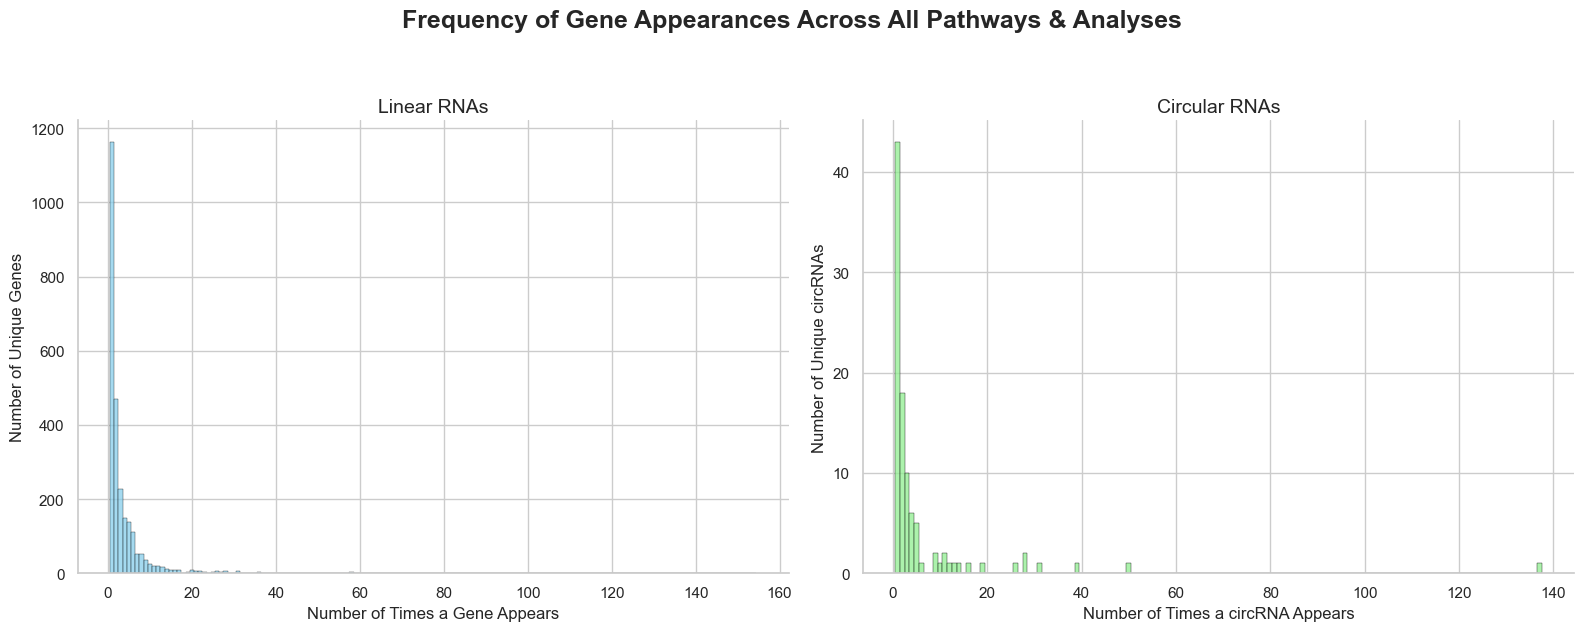

========== LINEAR RNAS ==========
Total unique linear genes: 2623
Most repeated linear gene appears 154 times.

Top 5 Most Repeated Linear RNAs:


linRNA_ID
ENSG00000100030.14    154
ENSG00000171608.16    137
ENSG00000112062.10     93
ENSG00000102882.12     91
ENSG00000100906.10     81
Name: count, dtype: int64


========== CIRCULAR RNAS ==========
Total unique circRNAs: 100
Most repeated circRNA appears 137 times.

Top 5 Most Repeated Circular RNAs:


circRNA_ID
chr1_9671013_9671353_+        137
chr10_48401612_48410168_+      50
chr6_149369909_149379518_+     39
chr15_98707562_98708107_+      31
chr22_20933779_20934244_+      28
Name: count, dtype: int64

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

# Grab the valid subsets
mapped_lin = final_df[final_df['linRNA_ID'].notna()]
mapped_circ = final_df[final_df['circRNA_ID'].notna()]

# Calculate how many times each specific ID appears
lin_counts = mapped_lin['linRNA_ID'].value_counts()
circ_counts = mapped_circ['circRNA_ID'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Frequency of Gene Appearances Across All Pathways & Analyses', fontsize=18, fontweight='bold', y=1.05)

# Linear RNA Frequency Histogram
# Using discrete=True forces the bins to cleanly align with whole numbers (1, 2, 3...)
sns.histplot(lin_counts, ax=axes[0], color='skyblue', edgecolor='black', discrete=True)
axes[0].set_title('Linear RNAs', fontsize=14)
axes[0].set_xlabel('Number of Times a Gene Appears', fontsize=12)
axes[0].set_ylabel('Number of Unique Genes', fontsize=12)

# Circular RNA Frequency Histogram
sns.histplot(circ_counts, ax=axes[1], color='lightgreen', edgecolor='black', discrete=True)
axes[1].set_title('Circular RNAs', fontsize=14)
axes[1].set_xlabel('Number of Times a circRNA Appears', fontsize=12)
axes[1].set_ylabel('Number of Unique circRNAs', fontsize=12)

sns.despine()
plt.tight_layout()
plt.show()

# Print out the exact stats so you don't have to guess from the chart
print(f"========== LINEAR RNAS ==========")
print(f"Total unique linear genes: {len(lin_counts)}")
print(f"Most repeated linear gene appears {lin_counts.max()} times.")
print("\nTop 5 Most Repeated Linear RNAs:")
display(lin_counts.head(5))

print(f"\n========== CIRCULAR RNAS ==========")
print(f"Total unique circRNAs: {len(circ_counts)}")
print(f"Most repeated circRNA appears {circ_counts.max()} times.")
print("\nTop 5 Most Repeated Circular RNAs:")
display(circ_counts.head(5))


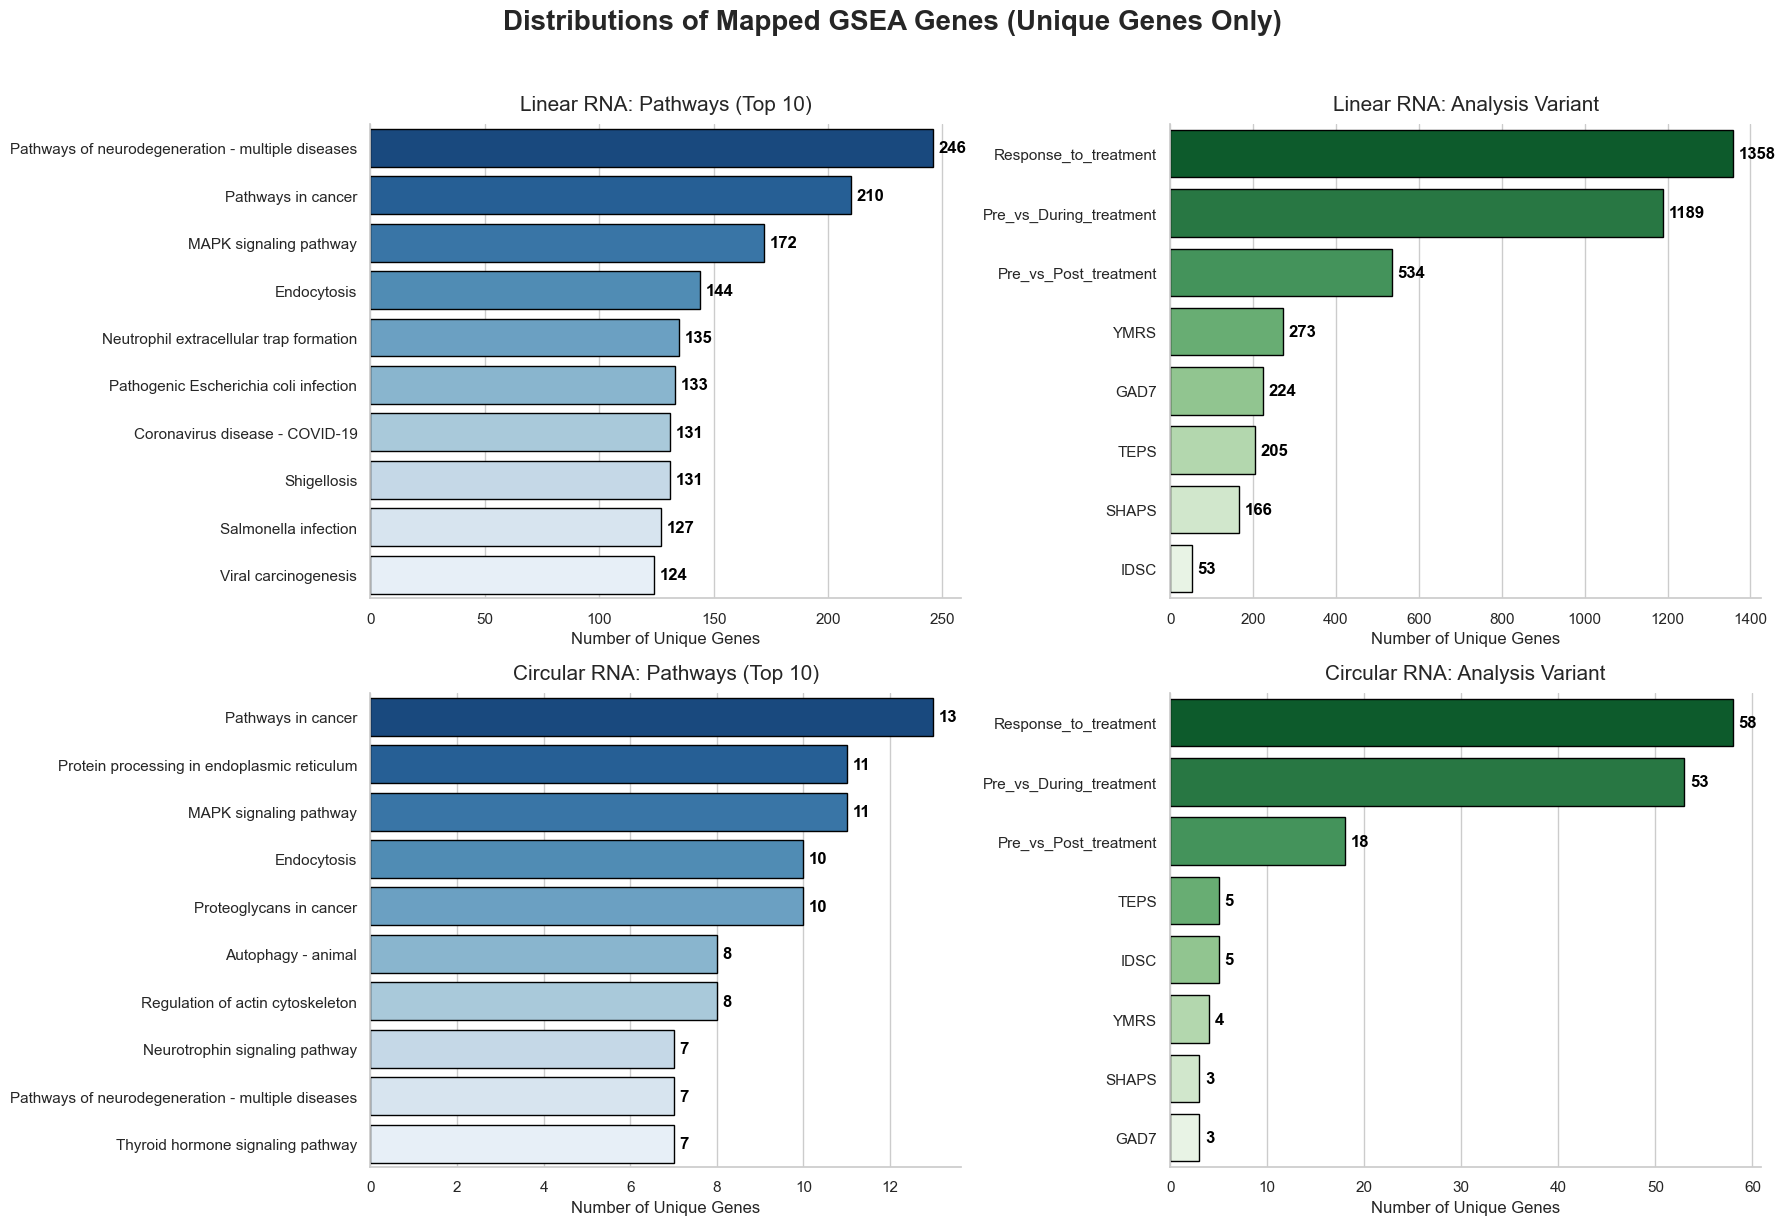

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Grab the valid subsets
mapped_lin = final_df[final_df['linRNA_ID'].notna()]
mapped_circ = final_df[final_df['circRNA_ID'].notna()]

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Distributions of Mapped GSEA Genes (Unique Genes Only)', fontsize=20, fontweight='bold', y=1.02)

# Helper function to plot clean, sorted horizontal bar charts
def plot_sorted_bars(data_series, ax, title, color_palette):
    counts = data_series.value_counts().sort_values(ascending=False)
    
    # Prevent chart squashing by only showing the Top 10
    if len(counts) > 10:
        counts = counts.head(10)
        title += " (Top 10)"
        
    sns.barplot(x=counts.values, y=counts.index, ax=ax, palette=color_palette, edgecolor='black')
    ax.set_title(title, fontsize=15, pad=10)
    ax.set_xlabel('Number of Unique Genes', fontsize=12)
    ax.set_ylabel('')
    
    # Add exact count labels to the end of each bar
    max_val = counts.max()
    for i, v in enumerate(counts.values):
        ax.text(v + (max_val * 0.01), i, str(v), color='black', va='center', fontweight='bold')
    
    sns.despine(ax=ax)


# --- DEDUPLICATION LOGIC ---
# Count a specific linear gene only ONCE per Pathway, and ONCE per Analysis
lin_unique_pathways = mapped_lin.drop_duplicates(subset=['linRNA_ID', 'Description'])['Description']
lin_unique_analyses = mapped_lin.drop_duplicates(subset=['linRNA_ID', 'analysis_name'])['analysis_name']

# Count a specific circRNA only ONCE per Pathway, and ONCE per Analysis
circ_unique_pathways = mapped_circ.drop_duplicates(subset=['circRNA_ID', 'Description'])['Description']
circ_unique_analyses = mapped_circ.drop_duplicates(subset=['circRNA_ID', 'analysis_name'])['analysis_name']
# ---------------------------


# 1. Linear RNA: Pathway Description
plot_sorted_bars(lin_unique_pathways, axes[0, 0], f'Linear RNA: Pathways', 'Blues_r')

# 2. Linear RNA: Analysis Variant
plot_sorted_bars(lin_unique_analyses, axes[0, 1], f'Linear RNA: Analysis Variant', 'Greens_r')

# 3. Circular RNA: Pathway Description
plot_sorted_bars(circ_unique_pathways, axes[1, 0], f'Circular RNA: Pathways', 'Blues_r')

# 4. Circular RNA: Analysis Variant
plot_sorted_bars(circ_unique_analyses, axes[1, 1], f'Circular RNA: Analysis Variant', 'Greens_r')

plt.tight_layout()
plt.show()
